# Exercise 2

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

*1. What is the survival rate ?*

In [32]:
df = pd.read_csv('Lab1_Ex2_titanic.csv')
df.head(10)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


In [33]:
df['survived'].value_counts(normalize=True)

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

**Answer:**

Survival rate (survived = 1) is **0.3820** (~**38.20%**).

*2. Gender distribution (sex)*

In [34]:
df['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

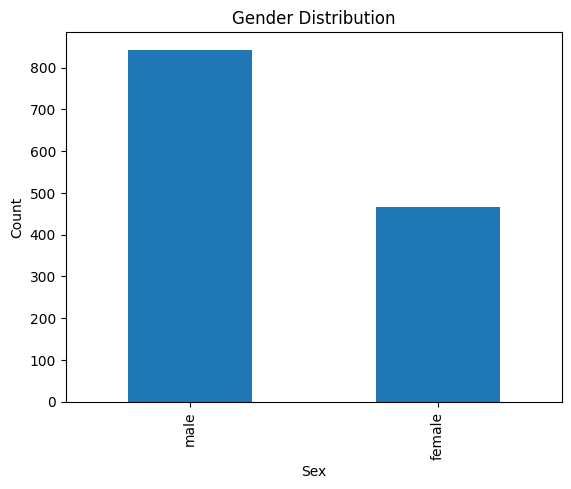

In [35]:
df['sex'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

**Answer:**

- male: **843**
- female: **466**

*3. Ticket class distribution (pclass)*

In [36]:
df['pclass'].value_counts().sort_index()

pclass
1    323
2    277
3    709
Name: count, dtype: int64

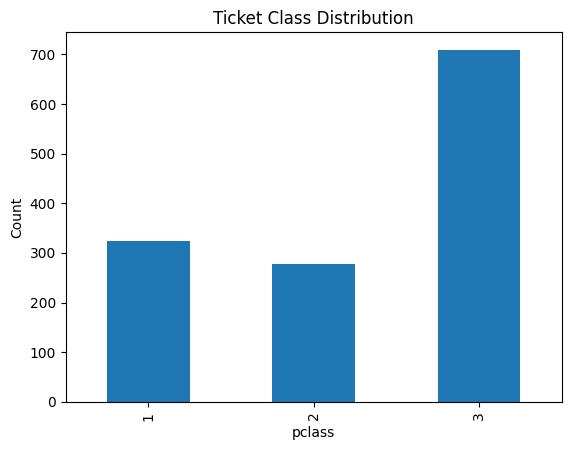

In [37]:
df['pclass'].value_counts().sort_index().plot(kind='bar')
plt.title('Ticket Class Distribution')
plt.xlabel('pclass')
plt.ylabel('Count')
plt.show()

**Answer:**

pclass
1    323
2    277
3    709

*4. Age distribution (age)*

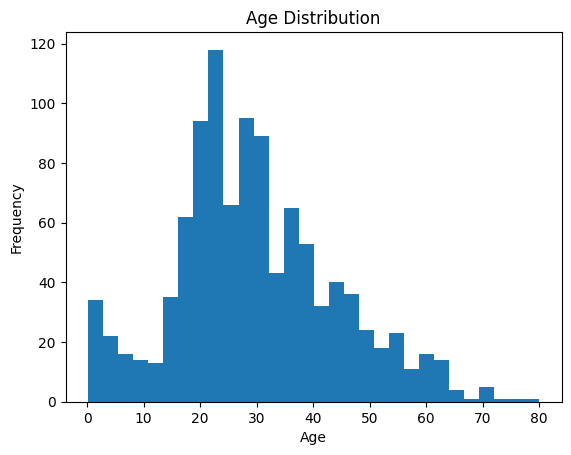

In [38]:
plt.hist(df['age'].dropna(), bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [39]:
df['age'].describe()

count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

**Answer:**

Most passengers are concentrated around **20–40** years old (median ≈ **28**).

*5. Survival rate by gender*

In [40]:
pd.crosstab(df['sex'], df['survived'], normalize='index')

survived,0,1
sex,,
female,0.272532,0.727468
male,0.809015,0.190985


**Answer:**

Survival rate by gender (row-normalized):

survived         0         1
sex                         
female    0.272532  0.727468
male      0.809015  0.190985

*6. Survival rate by ticket class (pclass)*

In [41]:
pd.crosstab(df['pclass'], df['survived'], normalize='index').sort_index()

survived,0,1
pclass,,
1,0.380805,0.619195
2,0.570397,0.429603
3,0.744711,0.255289


**Answer:**

Survival rate by class (row-normalized):

survived         0         1
pclass                      
1         0.380805  0.619195
2         0.570397  0.429603
3         0.744711  0.255289

*7. Survival rate by age group*

In [42]:
age_bins = [0, 12, 18, 60, 100]
age_labels = ['child', 'teen', 'adult', 'senior']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, include_lowest=True)
pd.crosstab(df['age_group'], df['survived'], normalize='index')

survived,0,1
age_group,,
child,0.425532,0.574468
teen,0.585859,0.414141
adult,0.604878,0.395122
senior,0.757576,0.242424


**Answer:**

Using age groups ['child', 'teen', 'adult', 'senior']: 

survived          0         1
age_group                    
child      0.425532  0.574468
teen       0.585859  0.414141
adult      0.604878  0.395122
senior     0.757576  0.242424

*8. Compare fare between survivors and non-survivors using a boxplot*

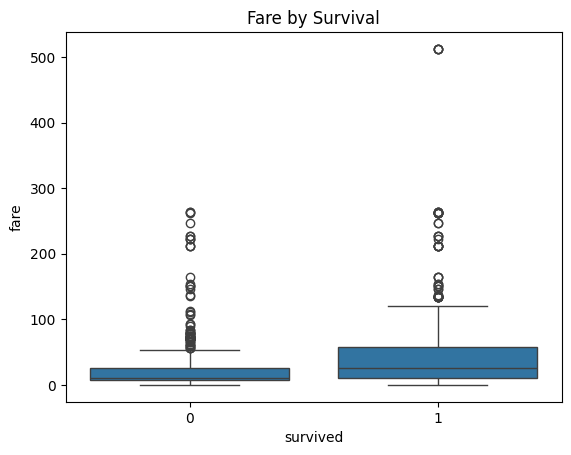

In [43]:
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Fare by Survival')
plt.show()

**Answer:**

Median fare:

survived
0    10.5
1    26.0.

Survivors generally paid higher fares (higher median and more high-fare outliers).

*9. How many rows and columns does the dataset have ?*

In [44]:
df.shape

(1309, 15)

**Answer:**

Dataset has **1309 rows** and **14 columns**.

*10. What is the meaning of each variable (pclass, sibsp, parch, boat, body, etc.)?*

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   int64   
 2   name       1309 non-null   object  
 3   sex        1309 non-null   object  
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   object  
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
 14  age_group  1046 non-null   category
dtypes: category(1), float64(3), int64(4), object(7)
memory usage: 144.8+ KB


**Answer:**

- **pclass**: ticket class (1=Upper, 2=Middle, 3=Lower)
- **survived**: survival status (1=survived, 0=died)
- **name**: passenger name
- **sex**: gender
- **age**: age (years)
- **sibsp**: number of siblings/spouses aboard
- **parch**: number of parents/children aboard
- **ticket**: ticket number
- **fare**: ticket fare
- **cabin**: cabin number
- **embarked**: port of embarkation (C/Q/S)
- **boat**: lifeboat number (if survived)
- **body**: body identification number (if deceased)
- **home.dest**: passenger’s last known residence

(These definitions follow the Exercise 2 description.)

*11. Is the survival variable (survived) imbalanced ?*

In [46]:
df['survived'].value_counts(normalize=True)

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

**Answer:**

Class distribution:

survived
0    0.618029
1    0.381971

Imbalance ratio (0/1) ≈ **1.62** → mildly/moderately imbalanced.

*12. Check columns with missing values: age, cabin, embarked, boat, body, home.dest*

In [47]:
df[['age','cabin','embarked','boat','body','home.dest']].isnull().sum().sort_values(ascending=False)

body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
dtype: int64

**Answer:**

Top missing columns (counts):

body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1

*13. Should we remove columns such as: name, ticket, boat, body ? Why ?*

**Answer:**

- **boat** and **body** should be removed for modeling because they contain *post-event information* (lifeboat/body id) that strongly leaks the target **survived**.
- **ticket** is high-cardinality and often not directly meaningful without heavy feature engineering.
- **name** is also high-cardinality, but you *can* keep it temporarily to extract useful signals such as **Title (Mr/Mrs/Miss/Master, …)**, then drop the raw name.

*14. Handle missing values in: age (fill with mean/median or by group: sex + pclass ?) embarked (fill with mode ?)*

In [48]:
df2 = df.copy()
# embarked: fill with mode
emb_mode = df2['embarked'].mode().iloc[0]
df2['embarked'] = df2['embarked'].fillna(emb_mode)

# fare: fill the single missing value with median (optional but safe)
df2['fare'] = df2['fare'].fillna(df2['fare'].median())

# age: fill by median within (sex, pclass)
group_median_age = df2.groupby(['sex','pclass'])['age'].transform('median')
df2['age'] = df2['age'].fillna(group_median_age)
# fallback
df2['age'] = df2['age'].fillna(df2['age'].median())

df2[['age','embarked','fare']].isnull().sum()

age         0
embarked    0
fare        0
dtype: int64

**Answer:**

- embarked filled with mode: **S**.
- age filled using median by (sex, pclass), then fallback to overall median.
- fare missing filled with median.


*15. Check and handle duplicate records*

In [49]:
df2.duplicated().sum()

0

**Answer:**

Number of duplicated rows: **0** (so no removal needed).

*16. Encode categorical variables: sex, embarked, pclass*

In [50]:
df_encoded = pd.get_dummies(df2, columns=['sex','embarked','pclass'], drop_first=False)
df_encoded[['survived'] + [c for c in df_encoded.columns if c.startswith('sex_') or c.startswith('embarked_') or c.startswith('pclass_')]].head()

,survived,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,pclass_1,pclass_2,pclass_3
0,1,True,False,False,False,True,True,False,False
1,1,False,True,False,False,True,True,False,False
2,0,True,False,False,False,True,True,False,False
3,0,False,True,False,False,True,True,False,False
4,0,True,False,False,False,True,True,False,False


**Answer:**

Use **one-hot encoding** for `sex`, `embarked`, and `pclass` because they are nominal categories (no numeric order).

*17. Should we normalize variables such as age and fare? When is normalization necessary?*

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df2.copy()
df_scaled[['age','fare']] = scaler.fit_transform(df_scaled[['age','fare']])
df_scaled[['age','fare']].describe()

,age,fare
count,1.309000e+03,1.309000e+03
mean,8.685014e-17,4.342507e-17
std,1.000382e+00,1.000382e+00
min,-2.201937e+00,-6.434642e-01
25%,-5.495549e-01,-4.908050e-01
50%,-2.468280e-01,-3.640034e-01
75%,5.099892e-01,-3.878613e-02
max,3.839985e+00,9.262028e+00


**Answer:**

Normalization/standardization is typically necessary when using **distance-based** or **gradient-based** models (e.g., KNN, SVM, Logistic Regression, Neural Networks) so features on larger scales (like fare) don’t dominate.
For **tree-based** models (Decision Tree, Random Forest, XGBoost), scaling is usually **not required**.

*18. Extract Title (Mr, Mrs, Miss, Master, etc.) from the name column. Should these titles be used as a new feature?*

In [52]:
df2['title'] = df2['name'].str.extract(r',\s*([^.]*)\.', expand=False).str.strip()
df2['title'].value_counts().head(15)

title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Mlle              2
Ms                2
Major             2
Capt              1
Sir               1
Dona              1
Jonkheer          1
the Countess      1
Name: count, dtype: int64

**Answer:**

Top titles:

title
Mr        757
Miss      260
Mrs       197
Master     61
Rev         8
Dr          8
Col         4
Mlle        2
Ms          2
Major       2

Yes—**Title** is often a useful engineered feature because it correlates with **gender, age group, and social status**, which in turn relate to survival odds.

*19. Create new features: family_size and is_alone*

In [53]:
df2['family_size'] = df2['sibsp'] + df2['parch'] + 1
df2['is_alone'] = np.where(df2['family_size'] == 1, 1, 0)
df2[['sibsp','parch','family_size','is_alone']].head()

,sibsp,parch,family_size,is_alone
0,0,0,1,1
1,1,2,4,0
2,1,2,4,0
3,1,2,4,0
4,1,2,4,0


**Answer:**

Created:
- `family_size = sibsp + parch + 1`
- `is_alone = 1 if family_size == 1 else 0`

*20. Create age groups: child, adult, senior*

In [54]:
df2['age_group3'] = pd.cut(df2['age'], bins=[0, 12, 60, 100], labels=['child','adult','senior'], include_lowest=True)
df2['age_group3'].value_counts(dropna=False)

age_group3
adult     1182
child       94
senior      33
Name: count, dtype: int64

**Answer:**

Created `age_group3` with bins:
- child: 0–12
- adult: 13–60
- senior: 61–100

*21. Create variable: cabin_known (có thông tin cabin hay không)*

In [55]:
df2['cabin_known'] = np.where(df2['cabin'].notnull(), 1, 0)
df2['cabin_known'].value_counts()

cabin_known
0    1014
1     295
Name: count, dtype: int64

**Answer:**

`cabin_known = 1` if cabin is available, otherwise `0`.

*22. Create variable fare_per_person = fare / family_size*

In [56]:
df2['fare_per_person'] = df2['fare'] / df2['family_size']
df2[['fare','family_size','fare_per_person']].head()

,fare,family_size,fare_per_person
0,211.3375,1,211.3375
1,151.5500,4,37.8875
2,151.5500,4,37.8875
3,151.5500,4,37.8875
4,151.5500,4,37.8875


**Answer:**

Created `fare_per_person` to normalize ticket fare by group size.

*23. Check for outliers in: fare, age*

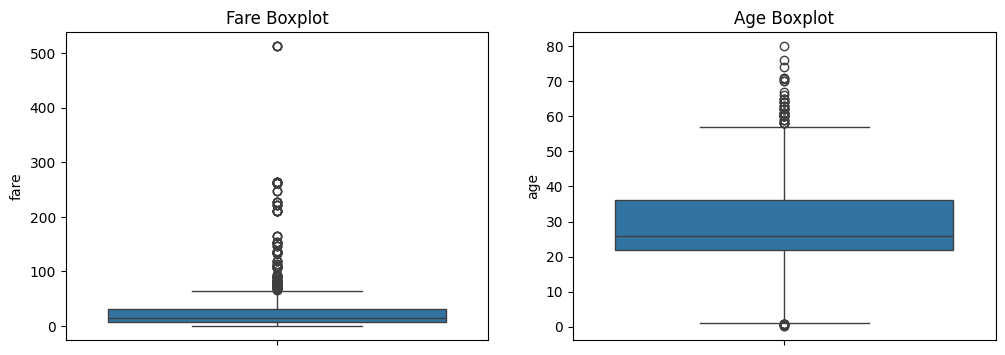

In [57]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(y=df2['fare'], ax=ax[0])
ax[0].set_title('Fare Boxplot')
sns.boxplot(y=df2['age'], ax=ax[1])
ax[1].set_title('Age Boxplot')
plt.show()

In [58]:
# IQR method for fare and age
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    out = series[(series < lower) | (series > upper)]
    return lower, upper, out

fare_lower, fare_upper, fare_out = iqr_outliers(df2['fare'])
age_lower, age_upper, age_out = iqr_outliers(df2['age'])
len(fare_out), len(age_out), (fare_lower, fare_upper), (age_lower, age_upper)

(171, 61, (-27.172999999999995, 66.34379999999999), (1.0, 57.0))

**Answer:**

- Fare IQR bounds: [-27.17, 66.34] → **171** outliers.
- Age IQR bounds: [1.00, 57.00] → **61** outliers.

Whether to cap/remove outliers depends on the modeling goal. For many models, you can keep them or apply winsorization/log-transform (for fare).

*24. Should we handle fare = 0?*

In [59]:
df2[df2['fare'] == 0].head()

(df2['fare'] == 0).sum(), (df2['fare'] == 0).mean()

(17, 0.012987012987012988)

**Answer:**

There are **17** records with `fare = 0` (≈ **1.30%**).

Because this proportion is small, you **may**:
- Keep them as-is if they are plausible (e.g., special cases), or
- Replace 0 with median/NaN then impute if you believe 0 is an error.
Decision should be based on domain assumptions and downstream model sensitivity.